# Compare Forward Tokenizers — char vs WordPiece

Reads the output of `scripts/compare_forward_tokenizers.py` (`raw_results.csv` +
`summary.json`) and, optionally, `scripts/calc_tokenization_stats.py`'s output for the
same AIRR file, and renders the comparison as tables and plots.

Interpretation notes live in markdown cells next to each plot, not on the plots
themselves — the plots only show data (axes, legend identifying which series is which).

In [1]:
# parameters
RESULTS_DIR = "../artifacts/compare_forward_tokenizers_2026-08-01_fine_grid_individual_maxlen_maxtokenlen9_anchored_40epochs"
DOMAIN_TOKENIZATION_STATS_PATH = "../artifacts/REPLACE_ME_domain_stats/tokenization_stats.json"

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_dir = Path(RESULTS_DIR)
raw = pd.read_csv(results_dir / "raw_results.csv")
with open(results_dir / "summary.json") as f:
    summary = json.load(f)

wp = sorted((r for r in summary if r["tokenizer"] == "wordpiece"), key=lambda r: r["vocab_size"])
char_row = next(r for r in summary if r["tokenizer"] == "char")
vocab_sizes = [r["vocab_size"] for r in wp]

# This notebook assumes one wordpiece config per vocab_size. If RESULTS_DIR mixes
# multiple --max-token-len/--pad-layout variants for the same vocab_size (e.g. after
# merging runs), that assumption breaks silently in the plots below - fail loudly instead.
if len(vocab_sizes) != len(set(vocab_sizes)):
    dupes = sorted({vs for vs in vocab_sizes if vocab_sizes.count(vs) > 1})
    raise ValueError(
        f"vocab_size {dupes} appears more than once in summary.json (different "
        "max_token_len/pad_layout variants mixed in one RESULTS_DIR) - this notebook "
        "isn't designed to compare those side by side; filter raw_results.csv/summary.json "
        "to a single max_token_len+pad_layout combination first."
    )

print(f"Loaded {len(raw)} individual runs across {len(summary)} tokenizer configs from {results_dir}")
raw.head()

Loaded 15 individual runs across 15 tokenizer configs from ..\artifacts\compare_forward_tokenizers_2026-08-01_fine_grid_individual_maxlen_maxtokenlen9_anchored_40epochs


,tokenizer,vocab_size,max_token_len,pad_layout,max_len,seed,test_loss,test_cosine,best_val_loss,epochs_to_best_val,train_time_sec,inference_time_sec,num_parameters,tokenizer_path
0,char,25,NaN,end,40,1,0.197678,0.867836,0.192469,33,1148.349279,0.551894,10850856,NaN
1,wordpiece,1000,9.0,anchored,11,1,0.222379,0.850060,0.219529,25,815.802114,0.472949,10913256,artifacts/tokenizers_2026-08-01_fine_grid/word...
2,wordpiece,2000,9.0,anchored,10,1,0.235747,0.840743,0.229570,27,800.566907,0.497766,10977256,artifacts/tokenizers_2026-08-01_fine_grid/word...
3,wordpiece,2998,9.0,anchored,10,1,0.242457,0.835847,0.240230,38,792.818900,0.469587,11041128,artifacts/tokenizers_2026-08-01_fine_grid/word...
4,wordpiece,3986,9.0,anchored,10,1,0.250418,0.830416,0.247915,38,793.682630,0.471941,11104360,artifacts/tokenizers_2026-08-01_fine_grid/word...


## Summary table (mean ± std across seeds)

In [3]:
def fmt(mean_std, precision=4):
    mean, std = mean_std
    return f"{mean:.{precision}f} \u00b1 {std:.{precision}f}"

summary_df = pd.DataFrame([
    {
        "tokenizer": row["tokenizer"],
        "vocab_size": row["vocab_size"],
        "test_loss": fmt(row["test_loss"]),
        "test_cosine": fmt(row["test_cosine"]),
        "best_val_loss": fmt(row["best_val_loss"]),
        "epochs_to_best_val": fmt(row["epochs_to_best_val"], precision=1),
        "num_parameters": row["num_parameters"],
        "n_seeds": row["n_seeds"],
    }
    for row in summary
])
summary_df

,tokenizer,vocab_size,test_loss,test_cosine,best_val_loss,epochs_to_best_val,num_parameters,n_seeds
0,char,25,0.1977 ± 0.0000,0.8678 ± 0.0000,0.1925 ± 0.0000,33.0 ± 0.0,10850856,1
1,wordpiece,1000,0.2224 ± 0.0000,0.8501 ± 0.0000,0.2195 ± 0.0000,25.0 ± 0.0,10913256,1
2,wordpiece,2000,0.2357 ± 0.0000,0.8407 ± 0.0000,0.2296 ± 0.0000,27.0 ± 0.0,10977256,1
3,wordpiece,2998,0.2425 ± 0.0000,0.8358 ± 0.0000,0.2402 ± 0.0000,38.0 ± 0.0,11041128,1
4,wordpiece,3986,0.2504 ± 0.0000,0.8304 ± 0.0000,0.2479 ± 0.0000,38.0 ± 0.0,11104360,1
5,wordpiece,4970,0.2559 ± 0.0000,0.8263 ± 0.0000,0.2540 ± 0.0000,36.0 ± 0.0,11167336,1
6,wordpiece,5951,0.2608 ± 0.0000,0.8232 ± 0.0000,0.2581 ± 0.0000,37.0 ± 0.0,11230120,1
7,wordpiece,6923,0.2668 ± 0.0000,0.8186 ± 0.0000,0.2650 ± 0.0000,37.0 ± 0.0,11292328,1
8,wordpiece,7897,0.2746 ± 0.0000,0.8128 ± 0.0000,0.2728 ± 0.0000,38.0 ± 0.0,11354664,1
9,wordpiece,8855,0.2818 ± 0.0000,0.8081 ± 0.0000,0.2801 ± 0.0000,36.0 ± 0.0,11415976,1


## 1. test_loss vs vocab_size

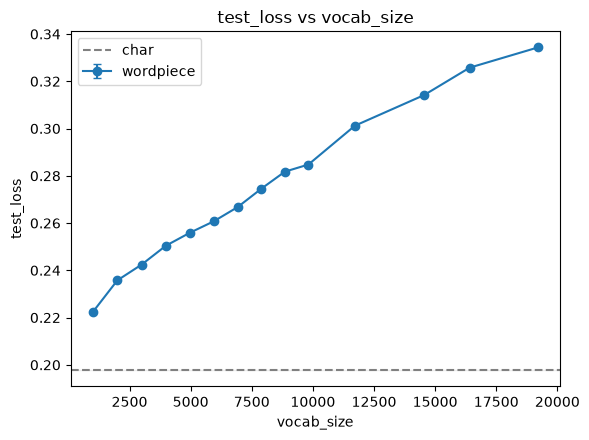

In [4]:
loss_means = [r["test_loss"][0] for r in wp]
loss_stds = [r["test_loss"][1] for r in wp]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.errorbar(vocab_sizes, loss_means, yerr=loss_stds, marker="o", capsize=3, label="wordpiece")
ax.axhline(char_row["test_loss"][0], color="gray", linestyle="--", label="char")
ax.axhspan(char_row["test_loss"][0] - char_row["test_loss"][1],
           char_row["test_loss"][0] + char_row["test_loss"][1], color="gray", alpha=0.15)
ax.set_xlabel("vocab_size")
ax.set_ylabel("test_loss")
ax.set_title("test_loss vs vocab_size")
ax.legend()
plt.tight_layout()
plt.show()

*Notes: lower `test_loss` is better. `char` has no `vocab_size` position of its own — it's
drawn as a horizontal reference (line + shaded std band), not a point on the WordPiece
ablation grid.*

## 2. test_cosine vs vocab_size

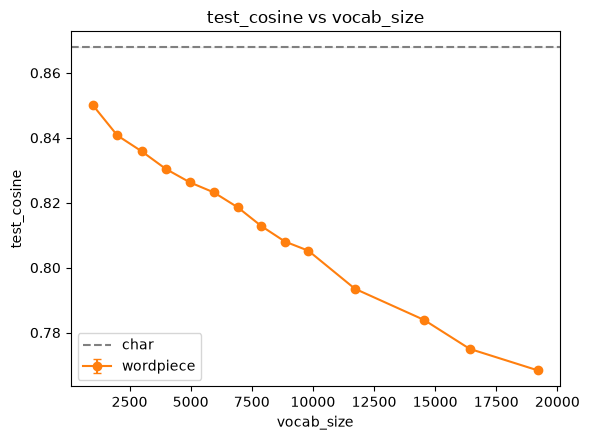

In [5]:
cos_means = [r["test_cosine"][0] for r in wp]
cos_stds = [r["test_cosine"][1] for r in wp]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.errorbar(vocab_sizes, cos_means, yerr=cos_stds, marker="o", capsize=3, color="tab:orange", label="wordpiece")
ax.axhline(char_row["test_cosine"][0], color="gray", linestyle="--", label="char")
ax.axhspan(char_row["test_cosine"][0] - char_row["test_cosine"][1],
           char_row["test_cosine"][0] + char_row["test_cosine"][1], color="gray", alpha=0.15)
ax.set_xlabel("vocab_size")
ax.set_ylabel("test_cosine")
ax.set_title("test_cosine vs vocab_size")
ax.legend()
plt.tight_layout()
plt.show()

*Notes: higher `test_cosine` is better.*

## 3. Per-seed spread of test_loss

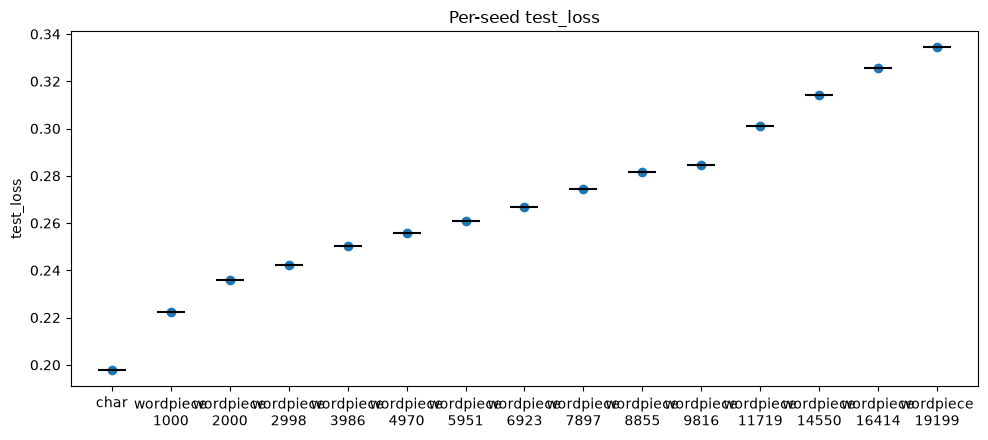

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
configs = sorted(raw[["tokenizer", "vocab_size"]].drop_duplicates().itertuples(index=False),
                  key=lambda c: (c.tokenizer, c.vocab_size))
labels = [f"{c.tokenizer}\n{c.vocab_size}" if c.tokenizer == "wordpiece" else "char" for c in configs]

for i, c in enumerate(configs):
    subset = raw[(raw["tokenizer"] == c.tokenizer) & (raw["vocab_size"] == c.vocab_size)]
    ax.scatter([i] * len(subset), subset["test_loss"], color="tab:blue", zorder=3)
    ax.scatter([i], [subset["test_loss"].mean()], color="black", marker="_", s=400, zorder=4)

ax.set_xticks(range(len(configs)))
ax.set_xticklabels(labels)
ax.set_ylabel("test_loss")
ax.set_title("Per-seed test_loss")
plt.tight_layout()
plt.show()

*Notes: each blue dot is one seed's `test_loss`; the black dash is the mean shown in the
summary table. Useful for checking whether a mean is being pulled around by a single
unusually good/bad seed rather than reflecting all three consistently.*

## 4. best_val_loss vs test_loss, by vocab_size

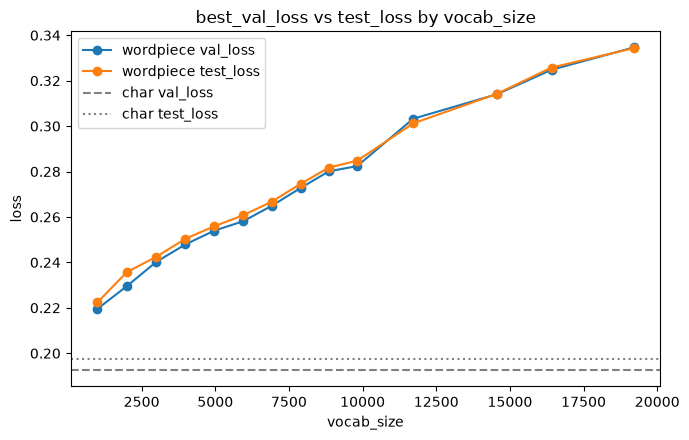

In [7]:
val_means = [r["best_val_loss"][0] for r in wp]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(vocab_sizes, val_means, marker="o", label="wordpiece val_loss")
ax.plot(vocab_sizes, loss_means, marker="o", label="wordpiece test_loss")
ax.axhline(char_row["best_val_loss"][0], color="gray", linestyle="--", label="char val_loss")
ax.axhline(char_row["test_loss"][0], color="gray", linestyle=":", label="char test_loss")
ax.set_xlabel("vocab_size")
ax.set_ylabel("loss")
ax.set_title("best_val_loss vs test_loss by vocab_size")
ax.legend()
plt.tight_layout()
plt.show()

*Notes: a wide, growing gap between the val and test lines for a given tokenizer would
point to overfitting to the validation split (or a val/test distribution mismatch); lines
staying close together across `vocab_size` suggests the ranking in plots 1-2 isn't an
artifact of overfitting.*

## 5. epochs_to_best_val, by config

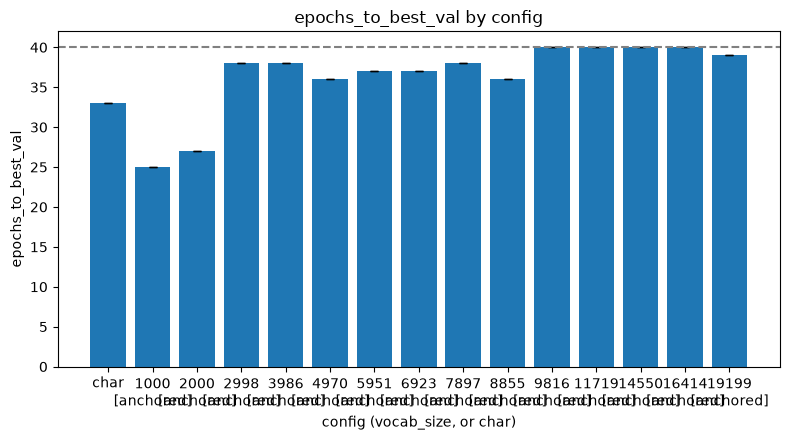

In [8]:
inferred_total_epochs = int(raw["epochs_to_best_val"].max())

group_cols = ["tokenizer", "vocab_size", "max_token_len", "pad_layout"]
conv = (
    raw.groupby(group_cols, dropna=False)["epochs_to_best_val"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(group_cols)
)
conv_labels = [
    "char" if t == "char" else f"{int(v)}" + ("" if pl == "end" else f"\n[{pl}]")
    for t, v, pl in zip(conv["tokenizer"], conv["vocab_size"], conv["pad_layout"])
]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(conv_labels, conv["mean"], yerr=conv["std"].fillna(0), capsize=3)
ax.axhline(inferred_total_epochs, color="gray", linestyle="--")
ax.set_xlabel("config (vocab_size, or char)")
ax.set_ylabel("epochs_to_best_val")
ax.set_title("epochs_to_best_val by config")
plt.tight_layout()
plt.show()

*Notes: the dashed line marks the last epoch of the run (`--epochs` used). A bar
reaching that line means best `val_loss` landed on the final epoch for at least some
seeds — i.e. training may not have plateaued yet for that config. See the per-seed
breakdown below for exactly how many of the 3 seeds hit that ceiling per config.*

In [9]:
def summarize_convergence(group):
    hit_ceiling = int((group["epochs_to_best_val"] == inferred_total_epochs).sum())
    return pd.Series({"seeds_hitting_ceiling": hit_ceiling, "n_seeds": len(group)})

ceiling_df = (
    raw.groupby(["tokenizer", "vocab_size", "max_token_len", "pad_layout"], dropna=False)
    .apply(summarize_convergence, include_groups=False)
    .reset_index()
)
ceiling_df["fraction_hitting_ceiling"] = ceiling_df["seeds_hitting_ceiling"] / ceiling_df["n_seeds"]
ceiling_df.sort_values("fraction_hitting_ceiling", ascending=False)

,tokenizer,vocab_size,max_token_len,pad_layout,seeds_hitting_ceiling,n_seeds,fraction_hitting_ceiling
12,wordpiece,14550,9.0,anchored,1,1,1.0
13,wordpiece,16414,9.0,anchored,1,1,1.0
10,wordpiece,9816,9.0,anchored,1,1,1.0
11,wordpiece,11719,9.0,anchored,1,1,1.0
0,char,25,NaN,end,0,1,0.0
1,wordpiece,1000,9.0,anchored,0,1,0.0
2,wordpiece,2000,9.0,anchored,0,1,0.0
6,wordpiece,5951,9.0,anchored,0,1,0.0
5,wordpiece,4970,9.0,anchored,0,1,0.0
4,wordpiece,3986,9.0,anchored,0,1,0.0


## 6. num_parameters vs test_loss

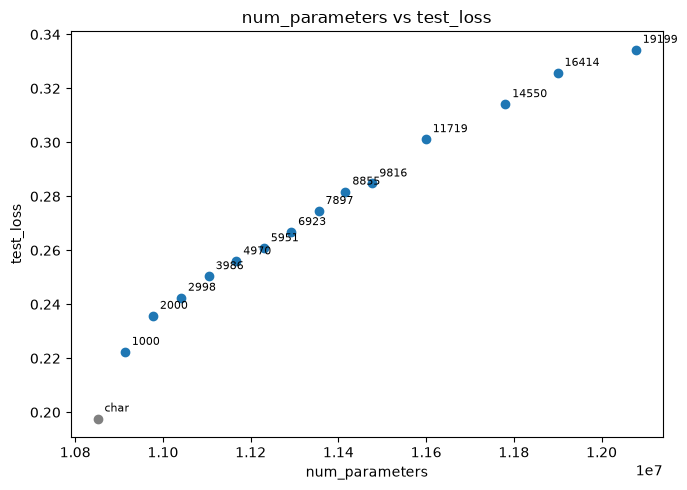

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for row in summary:
    label = "char" if row["tokenizer"] == "char" else str(row["vocab_size"])
    ax.scatter(row["num_parameters"], row["test_loss"][0],
               color="gray" if row["tokenizer"] == "char" else "tab:blue")
    ax.annotate(label, (row["num_parameters"], row["test_loss"][0]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("num_parameters")
ax.set_ylabel("test_loss")
ax.set_title("num_parameters vs test_loss")
plt.tight_layout()
plt.show()

*Notes: point labels identify which config each point is (`char`, or the WordPiece
`vocab_size`) - this is identification, not an interpretive claim. `char` has fewer
parameters than every WordPiece config here (smaller embedding table), which is worth
keeping in mind when comparing this plot against plots 1-2.*

## 7. train_time_sec by config

In [11]:
median_time = raw["train_time_sec"].median()
raw["time_ratio_vs_median"] = raw["train_time_sec"] / median_time
outliers = raw[raw["time_ratio_vs_median"] > 3]
clean = raw[raw["time_ratio_vs_median"] <= 3]

if len(outliers):
    print(f"Excluding {len(outliers)} run(s) with train_time_sec > 3x the median "
          f"(likely contaminated by something external, e.g. the machine sleeping mid-run):")
    print(outliers[["tokenizer", "vocab_size", "seed", "train_time_sec", "time_ratio_vs_median"]].to_string(index=False))

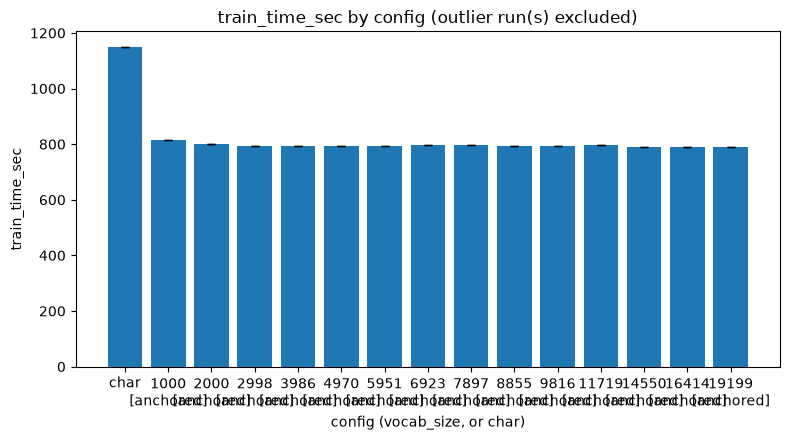

In [12]:
group_cols = ["tokenizer", "vocab_size", "max_token_len", "pad_layout"]
time_stats = (
    clean.groupby(group_cols, dropna=False)["train_time_sec"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(group_cols)
)
time_labels = [
    "char" if t == "char" else f"{int(v)}" + ("" if pl == "end" else f"\n[{pl}]")
    for t, v, pl in zip(time_stats["tokenizer"], time_stats["vocab_size"], time_stats["pad_layout"])
]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(time_labels, time_stats["mean"], yerr=time_stats["std"].fillna(0), capsize=3)
ax.set_xlabel("config (vocab_size, or char)")
ax.set_ylabel("train_time_sec")
ax.set_title("train_time_sec by config (outlier run(s) excluded)")
plt.tight_layout()
plt.show()

## 8. unk_token_fraction vs vocab_size, on this AIRR file

In [13]:
domain_stats_path = Path(DOMAIN_TOKENIZATION_STATS_PATH)

if not domain_stats_path.exists():
    print(f"Not found: {domain_stats_path}")
    print("Run scripts/calc_tokenization_stats.py on the same AIRR file used for the "
          "results above (pointed at the same --tokenizers-dir) to produce this file, "
          "then re-run this cell.")
else:
    with open(domain_stats_path) as f:
        domain_stats = json.load(f)
    per_vocab_size = domain_stats["per_vocab_size"]

    domain_vocab_sizes = [vs for vs in vocab_sizes if str(vs) in per_vocab_size]
    missing = [vs for vs in vocab_sizes if str(vs) not in per_vocab_size]
    if missing:
        print(f"No tokenization_stats entry for vocab_size={missing}; plotting only {domain_vocab_sizes}.")

    unk_fractions = [per_vocab_size[str(vs)]["splits"]["test"]["unk_token_fraction"] for vs in domain_vocab_sizes]

    fig, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.errorbar(vocab_sizes, loss_means, yerr=loss_stds, marker="o", color="tab:blue", label="test_loss")
    ax1.set_xlabel("vocab_size")
    ax1.set_ylabel("test_loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(domain_vocab_sizes, unk_fractions, marker="s", color="tab:red", label="unk_token_fraction (test split)")
    ax2.set_ylabel("unk_token_fraction", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    fig.suptitle("test_loss and unk_token_fraction vs vocab_size")
    fig.tight_layout()
    plt.show()

Not found: ..\artifacts\REPLACE_ME_domain_stats\tokenization_stats.json
Run scripts/calc_tokenization_stats.py on the same AIRR file used for the results above (pointed at the same --tokenizers-dir) to produce this file, then re-run this cell.


*Notes: `unk_token_fraction` here comes from running the WordPiece tokenizers on THIS
AIRR file's own test split (via `calc_tokenization_stats.py`), separately from the model
training run above. If this line rises steeply with `vocab_size` on this file - more so
than what `tokenizer_stats_report.ipynb` shows for the file the tokenizers were originally
trained on - that supports a domain-mismatch explanation for plots 1-2 rather than a
WordPiece-architecture explanation. If it stays flat/low, domain mismatch is less likely
to be the cause and the effect in plots 1-2 is more likely something else (e.g. see plot 5
for a convergence-based explanation).*